<a href="https://colab.research.google.com/github/azadeutsche114/Bag-of-words/blob/main/12_TSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series

In [ ]:
!wget https://raw.githubusercontent.com/nachikethmurthy/Source-Code-Dataset-for-Machine-Learning-using-Python/main/Data/SeaPlaneTravel.csv

--2022-09-14 03:09:38--  https://raw.githubusercontent.com/nachikethmurthy/Source-Code-Dataset-for-Machine-Learning-using-Python/main/Data/SeaPlaneTravel.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1746 (1.7K) [text/plain]
Saving to: ‘SeaPlaneTravel.csv’

SeaPlaneTravel.csv  100%[===================>]   1.71K  --.-KB/s    in 0s      

2022-09-14 03:09:38 (29.2 MB/s) - ‘SeaPlaneTravel.csv’ saved [1746/1746]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('SeaPlaneTravel.csv')
df.head()

,Month,#Passengers
0,2003-01,112
1,2003-02,118
2,2003-03,132
3,2003-04,129
4,2003-05,121


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
df = pd.read_csv('SeaPlaneTravel.csv', parse_dates=['Month'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [ ]:
df.set_index('Month',inplace=True)
df.columns = ['Passengers']
df.head()

,Passengers
Month,
2003-01-01,112
2003-02-01,118
2003-03-01,132
2003-04-01,129
2003-05-01,121


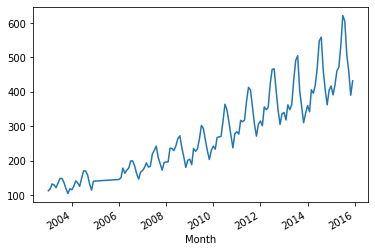

In [ ]:
df['Passengers'].plot()
plt.show()

In [ ]:
# From visual analysis - Non Stationary plot

# ADFULLER test

In [ ]:
from statsmodels.tsa.stattools import adfuller
p_value = adfuller(df['Passengers'])[1]
if p_value > 0.05:
  print("The give plot is a Non Stationary plot")
  print("p = ",p_value)

else:
  print("The given plot is a Stationary plot")
  print("p = ",p_value)

The give plot is a Non Stationary plot
p =  0.991880243437641


# Differencing

In [ ]:
df['Passengers'].diff().dropna()

Month
2003-02-01     6.0
2003-03-01    14.0
2003-04-01    -3.0
2003-05-01    -8.0
2003-06-01    14.0
              ... 
2015-08-01   -16.0
2015-09-01   -98.0
2015-10-01   -47.0
2015-11-01   -71.0
2015-12-01    42.0
Name: Passengers, Length: 143, dtype: float64

In [ ]:
from statsmodels.tsa.stattools import adfuller
p_value = adfuller(df['Passengers'].diff().dropna())[1]
if p_value > 0.05:
  print("The give plot is a Non Stationary plot")
  print("p = ",p_value)

else:
  print("The given plot is a Stationary plot")
  print("p = ",p_value)

The give plot is a Non Stationary plot
p =  0.054213290283824704


In [ ]:
from statsmodels.tsa.stattools import adfuller
p_value = adfuller(df['Passengers'].diff().diff().dropna())[1]
if p_value > 0.05:
  print("The give plot is a Non Stationary plot")
  print("p = ",p_value)

else:
  print("The given plot is a Stationary plot")
  print("p = ",p_value)

The given plot is a Stationary plot
p =  2.7328918500143186e-29


In [ ]:
# find p and q from ARIMA function
# Perform fit
# Generate prediction
# Evaluate the results